In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import precision_recall_curve, roc_curve
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import confusion_matrix
from sklearn.calibration import CalibrationDisplay
from scipy.stats import randint, uniform
import xgboost as xgb

# 🤖 Modelagem Preditiva de Churn — Treinamento, Avaliação e Otimização

Nesta seção, foi desenvolvido e avaliado um modelo preditivo de churn utilizando **XGBoost**, com foco não apenas na performance global, mas principalmente na **capacidade de priorização de clientes em risco**, alinhando o modelo ao contexto real de negócio.

O processo foi conduzido de forma estruturada, incluindo:

- Treinamento do modelo com hiperparâmetros otimizados
- Ajuste do threshold de decisão
- Avaliação com métricas estatísticas e de negócio
- Análise de separação, calibração e eficiência operacional

---


In [2]:
df = pd.read_parquet("../data/dataset_model.parquet")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customerid                7032 non-null   object 
 1   tenure                    7032 non-null   int64  
 2   monthlycharges            7032 non-null   float64
 3   totalcharges              7032 non-null   float64
 4   total_services            7032 non-null   int64  
 5   avg_charge_per_service    7032 non-null   float64
 6   seniorcitizen             7032 non-null   int64  
 7   automatic_payment         7032 non-null   int64  
 8   streaming_user            7032 non-null   int64  
 9   internet_and_phone        7032 non-null   int64  
 10  customer_lifecycle_stage  7032 non-null   object 
 11  gender                    7032 non-null   object 
 12  partner                   7032 non-null   object 
 13  dependents                7032 non-null   object 
 14  phoneser

In [4]:
#Transformando colunas "object" em "category" para uso do xgboost

cat_cols = df.select_dtypes(include='object').columns

df[cat_cols] = df[cat_cols].astype('category')

In [5]:
df.dtypes

customerid                  category
tenure                         int64
monthlycharges               float64
totalcharges                 float64
total_services                 int64
avg_charge_per_service       float64
seniorcitizen                  int64
automatic_payment              int64
streaming_user                 int64
internet_and_phone             int64
customer_lifecycle_stage    category
gender                      category
partner                     category
dependents                  category
phoneservice                category
multiplelines               category
internetservice             category
contract                    category
paperlessbilling            category
paymentmethod               category
onlinesecurity              category
onlinebackup                category
deviceprotection            category
techsupport                 category
streamingtv                 category
streamingmovies             category
target                         int64
d

In [6]:
df["monthlycharges"].describe()

count    7032.000000
mean       64.798208
std        30.085974
min        18.250000
25%        35.587500
50%        70.350000
75%        89.862500
max       118.750000
Name: monthlycharges, dtype: float64

In [7]:
df["total_services"].value_counts()

total_services
0    2213
3    1117
2    1033
1     966
4     850
5     569
6     284
Name: count, dtype: int64

In [8]:
df["tenure"].describe()

count    7032.000000
mean       32.421786
std        24.545260
min         1.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

In [9]:
df["avg_charge_per_service"].describe()

count    7032.000000
mean       33.715171
std        19.742766
min        10.416667
25%        19.950000
50%        25.400000
75%        44.256250
max        87.050000
Name: avg_charge_per_service, dtype: float64

<Axes: xlabel='avg_charge_per_service'>

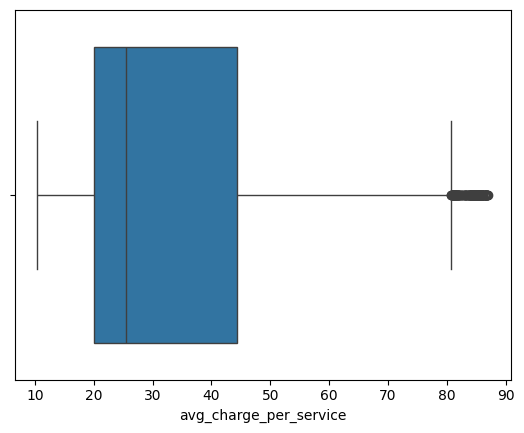

In [10]:
sns.boxplot(x=df["avg_charge_per_service"])

### 📊 Análise de Outliers e Consistência dos Dados

Antes da modelagem, foi realizada uma análise exploratória com foco na identificação de possíveis outliers nas variáveis numéricas.

📌 Insight:
Os valores extremos identificados são consistentes com o contexto do negócio, representando clientes com maior tempo de relacionamento ou maior nível de consumo, e não erros de coleta. Por esse motivo, esses dados foram mantidos, preservando a representatividade do comportamento real dos clientes e evitando distorções no treinamento do modelo.

In [11]:
df = df.drop(["customerid"], axis=1)

In [12]:
df.shape

(7032, 26)

In [13]:
X = df.drop(["target"], axis=1)
y = df["target"]

In [14]:
SEED = 42

In [15]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.25,
    stratify=y_train_full,
    random_state=42
)

In [16]:
model = xgb.XGBClassifier(objective='binary:logistic', enable_categorical=True)
model.fit(X_train, y_train)
pred = model.predict(X_test)

In [17]:
report = classification_report(y_test, pred)
print(report)

              precision    recall  f1-score   support

           0       0.83      0.87      0.85      1033
           1       0.59      0.51      0.55       374

    accuracy                           0.78      1407
   macro avg       0.71      0.69      0.70      1407
weighted avg       0.77      0.78      0.77      1407



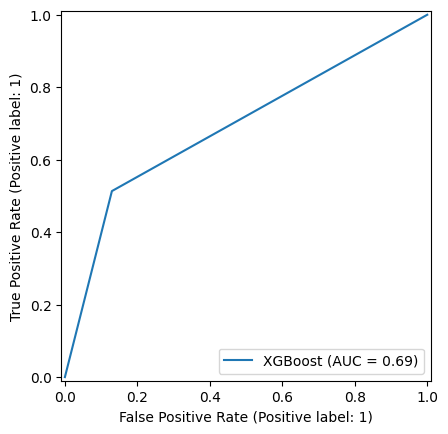

In [18]:
RocCurveDisplay.from_predictions(y_test, pred, name='XGBoost')

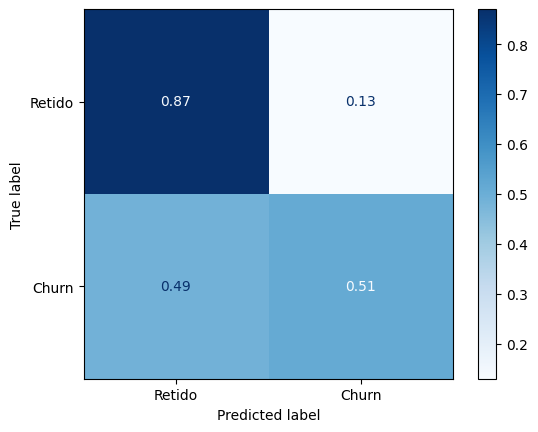

In [19]:
ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=["Retido", "Churn"], normalize='true', cmap="Blues")

In [20]:
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

In [21]:
model = xgb.XGBClassifier(objective='binary:logistic', enable_categorical=True, scale_pos_weight=scale_pos_weight, random_state=SEED)
model.fit(X_train, y_train)
pred = model.predict(X_test)

In [22]:
report = classification_report(y_test, pred)
print(report)

              precision    recall  f1-score   support

           0       0.86      0.81      0.83      1033
           1       0.54      0.63      0.59       374

    accuracy                           0.76      1407
   macro avg       0.70      0.72      0.71      1407
weighted avg       0.78      0.76      0.77      1407



# ⚙️ Treinamento do Modelo

O modelo escolhido foi o **XGBoost Classifier**, amplamente utilizado em problemas tabulares devido à sua alta capacidade de generalização e robustez.

Além disso, foi utilizado o parâmetro:

- `scale_pos_weight`: para compensar o desbalanceamento da base, aumentando a penalização de erros na classe minoritária (churn).

O modelo retorna como saída **probabilidades de churn**, permitindo flexibilidade na definição do threshold de decisão.

---

In [23]:
y_prob_val = model.predict_proba(X_val)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val, y_prob_val)

# pegar o menor threshold que mantém recall == 0.80
idx = np.where(recall[:-1] >= 0.80)[0]
threshold = thresholds[idx[-1]]

print(threshold)

0.21086432


In [24]:
# prob no test
y_prob_test = model.predict_proba(X_test)[:, 1]

# aplica threshold do VAL
y_pred_test = (y_prob_test >= threshold).astype(int)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_test))
print(classification_report(y_test, y_pred_test, digits=4))

print("Recall TEST:", recall_score(y_test, y_pred_test))
print("Precision TEST:", precision_score(y_test, y_pred_test))

Confusion Matrix:
 [[695 338]
 [ 72 302]]
              precision    recall  f1-score   support

           0     0.9061    0.6728    0.7722      1033
           1     0.4719    0.8075    0.5957       374

    accuracy                         0.7086      1407
   macro avg     0.6890    0.7401    0.6839      1407
weighted avg     0.7907    0.7086    0.7253      1407

Recall TEST: 0.8074866310160428
Precision TEST: 0.471875


In [25]:
#Melhor Threshold encontrado
THRESHOLD = 0.21

#Função que roda todo o threshold para aplicação no futuro 
def predict_churn(model, X, threshold):
    prob = model.predict_proba(X)[:, 1]
    pred = (prob >= threshold).astype(int)
    return prob, pred

In [26]:
model = xgb.XGBClassifier(objective='binary:logistic', enable_categorical=True, scale_pos_weight=scale_pos_weight, random_state=SEED)

params = {
    "n_estimators": randint(200, 1200),
    "max_depth": randint(2, 8),
    "learning_rate": uniform(0.01, 0.19),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "min_child_weight": randint(1, 12),
    "gamma": uniform(0.0, 5.0),
    "reg_lambda": uniform(0.0, 10.0)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

rs = RandomizedSearchCV(
    estimator=model,
    param_distributions=params,
    n_iter=80,
    scoring="f1",
    cv = cv,
    n_jobs=-1,
    random_state=SEED
)

rs.fit(X_train, y_train)

,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': <scipy.stats....0028DEE2ABA30>, 'gamma': <scipy.stats....0028DEE2AB160>, 'learning_rate': <scipy.stats....0028DEE2A9570>, 'max_depth': <scipy.stats....0028DED119960>, ...}"
,n_iter,80
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [27]:
print("Melhores parâmetros encontrados:", rs.best_params_)
print("F1-Score:", rs.best_score_)

Melhores parâmetros encontrados: {'colsample_bytree': np.float64(0.6203074124157587), 'gamma': np.float64(4.433085744753299), 'learning_rate': np.float64(0.015247186656003893), 'max_depth': 3, 'min_child_weight': 2, 'n_estimators': 999, 'reg_lambda': np.float64(5.78280140996174), 'subsample': np.float64(0.6143769095186968)}
F1-Score: 0.6405719274089946


In [28]:
best_model = xgb.XGBClassifier(
    objective="binary:logistic",
    enable_categorical=True,
    scale_pos_weight=scale_pos_weight,
    colsample_bytree=0.62, 
    gamma=4.4, 
    learning_rate=0.01, 
    max_depth=3,
    min_child_weight=2,
    n_estimators=999,
    reg_lambda=5.7,
    subsample=0.6
)

best_model.fit(X_train, y_train)
prob, pred = predict_churn(best_model, X_test, THRESHOLD)

In [29]:
print(classification_report(y_test, pred, digits=4))

              precision    recall  f1-score   support

           0     0.9541    0.4831    0.6414      1033
           1     0.3959    0.9358    0.5564       374

    accuracy                         0.6034      1407
   macro avg     0.6750    0.7094    0.5989      1407
weighted avg     0.8057    0.6034    0.6188      1407



# 🎯 Ajuste do Threshold de Decisão

Por padrão, modelos classificam utilizando threshold de 0.5. Entretanto, em problemas de churn, o objetivo principal é **maximizar a identificação de clientes em risco**, mesmo que isso gere mais falsos positivos.

Por isso, foi realizada uma análise de trade-off entre Precision e Recall, permitindo selecionar um threshold alinhado ao objetivo de negócio.

O gráfico abaixo demonstra esse comportamento:

- Threshold baixo → maior Recall, menor Precision
- Threshold alto → maior Precision, menor Recall

Foi selecionado um threshold que prioriza maior capacidade de identificação de churners.

---

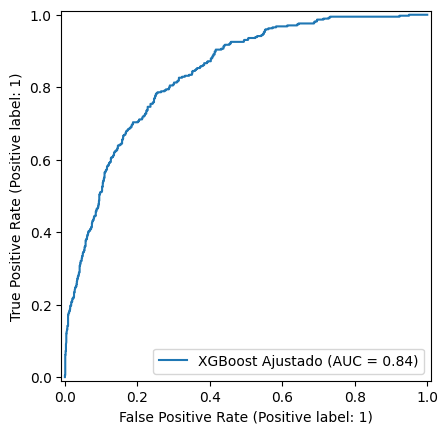

In [30]:
RocCurveDisplay.from_predictions(y_test, prob, name="XGBoost Ajustado")

Text(0.5, 1.0, 'Matriz de Confusão Normalizada - XGBoost Churn')

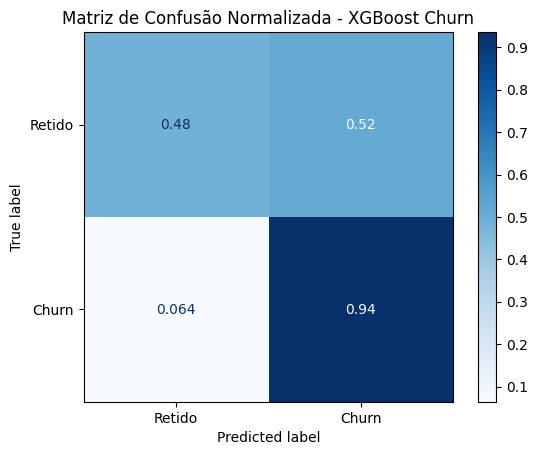

In [31]:
ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=["Retido", "Churn"], normalize='true', cmap='Blues')
plt.title("Matriz de Confusão Normalizada - XGBoost Churn")

# 📊 Classification Report e Matriz de Confusão

A matriz de confusão e o classification report permitem avaliar:

- Recall: capacidade de identificar churners
- Precision: proporção correta entre os clientes classificados como churn
- F1-score: equilíbrio entre precisão e cobertura

O modelo alcançou alta capacidade de identificação de churn, com recall superior a 93%, demonstrando forte capacidade de detecção.

---

# 📈 ROC Curve — Capacidade Geral de Separação

A curva ROC avalia a capacidade global do modelo em separar as classes.

O modelo apresentou:

**AUC = 0.84**

Isso indica que o modelo possui forte capacidade de discriminação entre clientes churn e não churn.

Quanto mais próxima a curva estiver do canto superior esquerdo, melhor a performance.

---

In [32]:
df_lift = pd.DataFrame({
    "y_true": y_test,
    "prob": prob
})

#Criar decis
df_lift['decil'] = pd.qcut(df_lift['prob'], 10, labels=False)

#Inverter ordem (maior risco primeiro)
df_lift['decil'] = 9 - df_lift['decil']

#Calcular Lift
lift_table = df_lift.groupby('decil').agg({
    "y_true": ["count", "sum"]
})

lift_table.columns = ["total", "churn"]
lift_table["churn_rate"] = lift_table["churn"] / lift_table["total"]
baseline = df_lift["y_true"].mean()
lift_table["lift"] = lift_table["churn_rate"] / baseline
lift_table

,total,churn,churn_rate,lift
decil,,,,
0,141,104,0.737589,2.774832
1,141,80,0.567376,2.134486
2,140,66,0.471429,1.773529
3,141,44,0.312057,1.173967
4,140,25,0.178571,0.671791
5,141,27,0.191489,0.720389
6,141,16,0.113475,0.426897
7,140,9,0.064286,0.241845
8,141,1,0.007092,0.026681


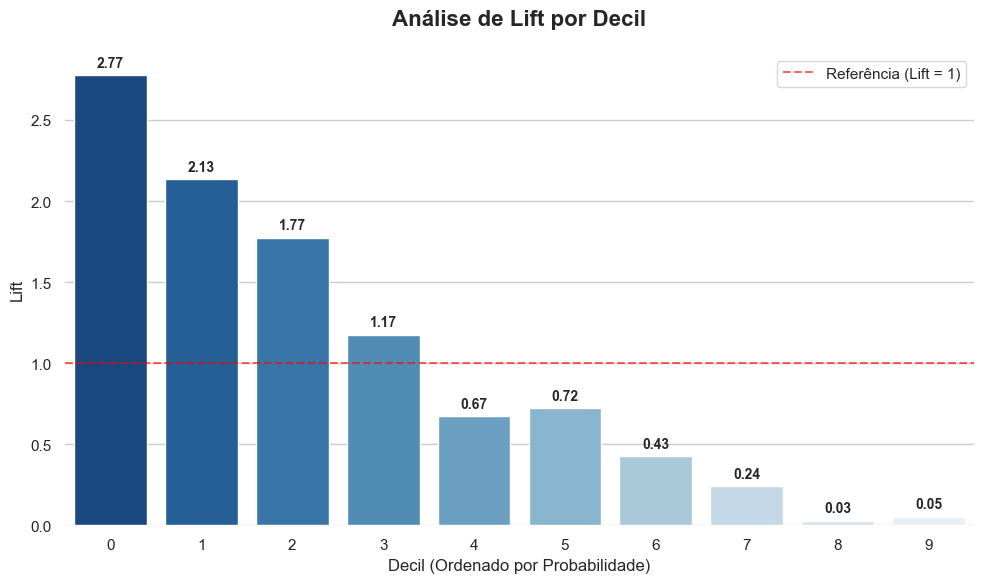

In [33]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

pal = sns.color_palette("Blues_r", len(lift_table))

# Plot principal
ax = sns.barplot(
    x=lift_table.index, 
    y=lift_table["lift"], 
    palette=pal,
    hue=lift_table.index, 
    legend=False
)

plt.axhline(1, color='red', linestyle='--', alpha=0.6, label="Referência (Lift = 1)")

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=10, fontweight='bold')

plt.title("Análise de Lift por Decil", fontsize=16, pad=20, fontweight='bold')
plt.xlabel("Decil (Ordenado por Probabilidade)", fontsize=12)
plt.ylabel("Lift", fontsize=12)
plt.xticks(rotation=0)

sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.legend()
plt.show()

# 📊 Lift Chart — Eficiência Operacional do Modelo

O Lift mede quantas vezes o modelo é melhor que uma seleção aleatória.

Resultado obtido:

**Lift no primeiro decil: 2.77**

Isso significa que os clientes com maior score possuem **2.77 vezes mais probabilidade de churn que a média da base**.

Esse é um forte indicativo de utilidade prática do modelo.

---

In [34]:
#Calcular FPR e TPR
fpr, tpr, thresholds = roc_curve(y_test, prob)

#Calcular KS
ks = np.max(tpr - fpr)
print("KS", ks)

KS 0.5307603108126997


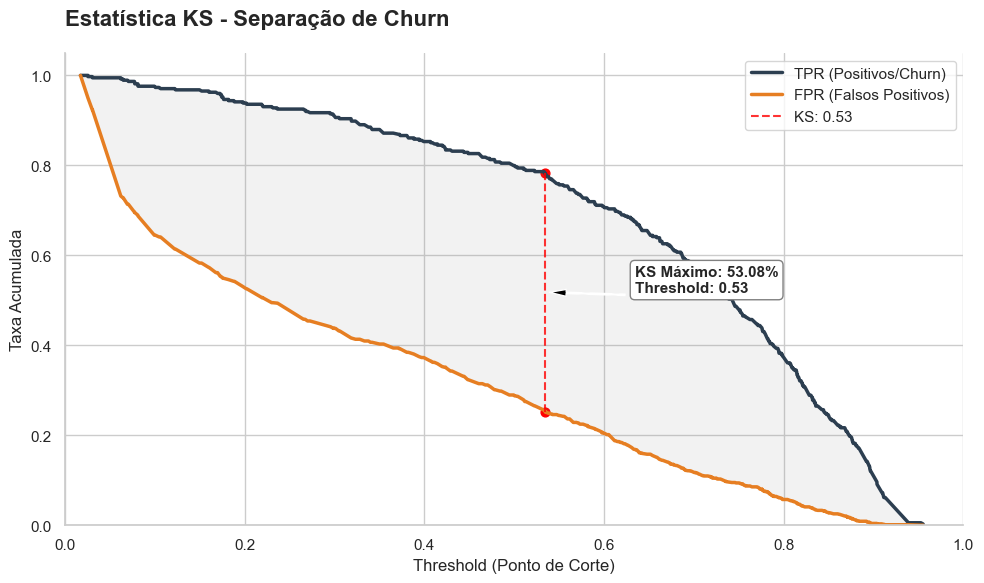

In [35]:
#Calculando o ponto KS (maior distância vertical)
ks_stat = np.max(tpr - fpr)
ks_idx = np.argmax(tpr - fpr)
x_ks = thresholds[ks_idx]
y_tpr = tpr[ks_idx]
y_fpr = fpr[ks_idx]

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

plt.plot(thresholds, tpr, label="TPR (Positivos/Churn)", color='#2c3e50', lw=2.5)
plt.plot(thresholds, fpr, label="FPR (Falsos Positivos)", color='#e67e22', lw=2.5)

plt.vlines(x_ks, y_fpr, y_tpr, color='red', linestyle='--', alpha=0.8, label=f'KS: {ks_stat:.2f}')
plt.scatter([x_ks, x_ks], [y_fpr, y_tpr], color='red', s=40)

plt.fill_between(thresholds, tpr, fpr, color='gray', alpha=0.1)

plt.annotate(f'KS Máximo: {ks_stat:.2%}\nThreshold: {x_ks:.2f}', 
             xy=(x_ks, (y_tpr + y_fpr)/2), 
             xytext=(x_ks+0.1, (y_tpr + y_fpr)/2),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
             fontsize=11, fontweight='bold', bbox=dict(boxstyle="round", fc="w", ec="0.5"))

plt.title("Estatística KS - Separação de Churn", fontsize=16, pad=20, fontweight='bold', loc='left')
plt.xlabel("Threshold (Ponto de Corte)", fontsize=12)
plt.ylabel("Taxa Acumulada", fontsize=12)
plt.xlim(0, 1)
plt.ylim(0, 1.05)

sns.despine()
plt.legend(frameon=True, facecolor='white')
plt.tight_layout()

plt.show()

# 📊 KS Statistic — Separação Estatística das Classes

O KS mede a máxima separação entre as distribuições de churn e não churn.

Resultado:

**KS = 0.53**

Valores acima de 0.5 indicam forte capacidade discriminativa.

Esse resultado confirma a robustez do modelo.

---

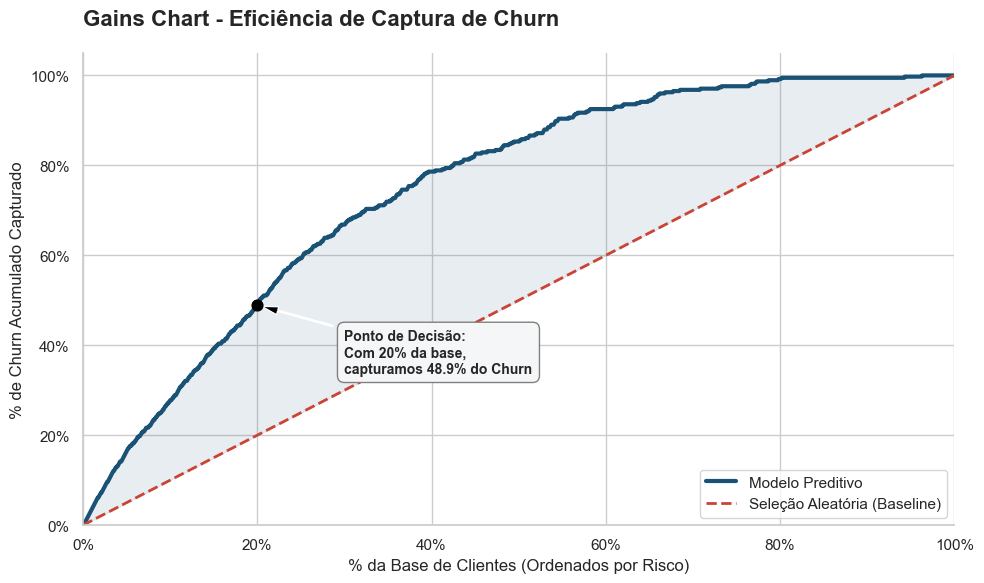

In [36]:
#Preparação dos dados para o Ganho Acumulado
#Ordenando as probabilidades reais de churn
df_gains = pd.DataFrame({'real': y_test, 'prob': prob})
df_gains = df_gains.sort_values('prob', ascending=False).reset_index(drop=True)

# Calculando percentuais acumulados
df_gains['cum_churn'] = df_gains['real'].cumsum() / df_gains['real'].sum()
df_gains['cum_base'] = (df_gains.index + 1) / len(df_gains)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

plt.plot(df_gains['cum_base'], df_gains['cum_churn'], color='#1a5276', lw=3, label='Modelo Preditivo')
plt.plot([0, 1], [0, 1], color='#cb4335', linestyle='--', lw=2, label='Seleção Aleatória (Baseline)')

top_percent = 0.20
gain_at_top = df_gains.iloc[int(len(df_gains)*top_percent)-1]['cum_churn']

plt.scatter(top_percent, gain_at_top, color='black', s=60, zorder=5)
plt.annotate(f'Ponto de Decisão:\nCom {top_percent:.0%} da base,\ncapturamos {gain_at_top:.1%} do Churn',
             xy=(top_percent, gain_at_top), xytext=(top_percent+0.1, gain_at_top-0.15),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
             fontsize=10, fontweight='bold', bbox=dict(boxstyle="round,pad=0.5", fc="#f4f6f7", ec="0.5"))

plt.fill_between(df_gains['cum_base'], df_gains['cum_churn'], df_gains['cum_base'], color='#1a5276', alpha=0.1)

plt.title("Gains Chart - Eficiência de Captura de Churn", fontsize=16, pad=20, fontweight='bold', loc='left')
plt.xlabel("% da Base de Clientes (Ordenados por Risco)", fontsize=12)
plt.ylabel("% de Churn Acumulado Capturado", fontsize=12)
plt.xlim(0, 1)
plt.ylim(0, 1.05)

plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

sns.despine()
plt.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.show()

# 📈 Gains Chart — Capacidade de Captura Acumulada

O Gains Chart mostra quanto churn é capturado ao priorizar os clientes com maior score.

Resultado observado:

**Com apenas 20% da base, o modelo captura 48.9% dos churners**

Isso demonstra alta eficiência operacional e potencial para campanhas de retenção direcionadas.

---

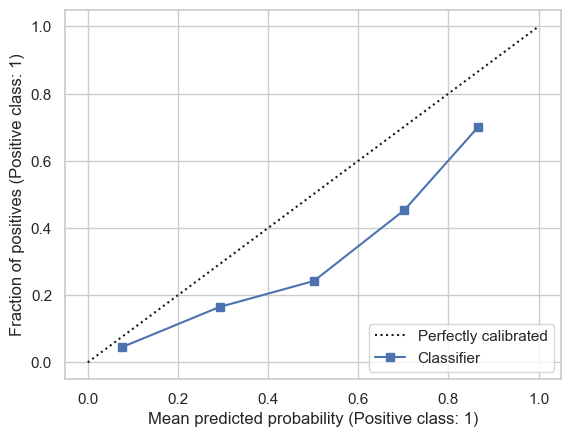

In [37]:
CalibrationDisplay.from_predictions(y_test, prob)

# 🎯 Calibration Curve — Confiabilidade das Probabilidades

A Calibration Curve avalia o quão próximas as probabilidades previstas estão da probabilidade real.

Observou-se leve superestimação das probabilidades, comportamento comum em modelos baseados em árvores.

Apesar disso, o modelo mantém excelente capacidade de ranking, conforme evidenciado pelas métricas anteriores.

---

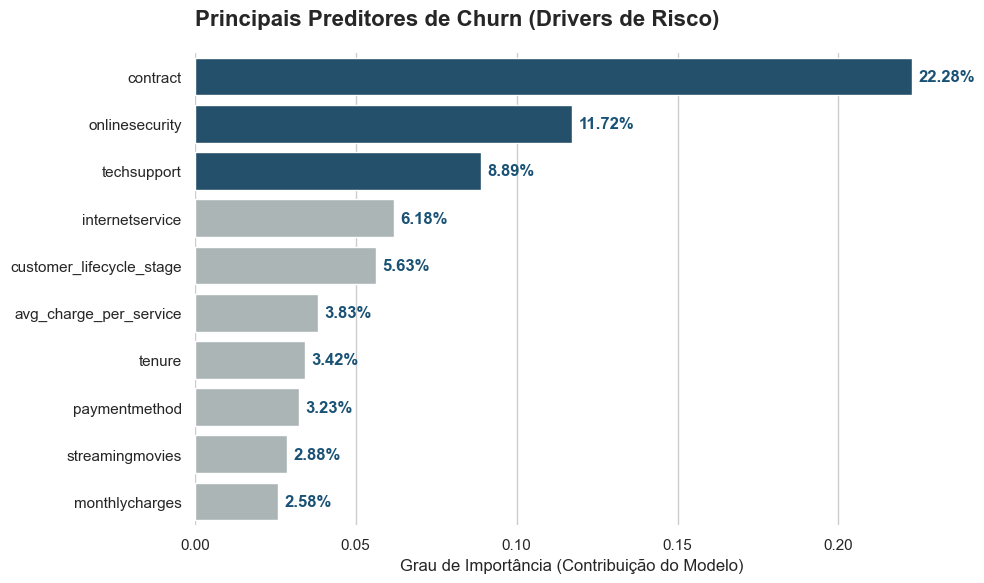

In [38]:
importances = best_model.feature_importances_

feat = pd.Series(importances, index=X_train.columns)

#Preparação dos dados (Top 10)
top_n = 10
feat_top = feat.sort_values(ascending=False).head(top_n)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

colors = ['#1a5276' if i < 3 else '#aab7b8' for i in range(top_n)]

ax = sns.barplot(x=feat_top.values, y=feat_top.index, palette=colors, hue=feat_top.index, legend=False)

for i, v in enumerate(feat_top.values):
    ax.text(v + 0.002, i, f'{v:.2%}', va='center', fontweight='bold', color='#1a5276')
plt.title("Principais Preditores de Churn (Drivers de Risco)", fontsize=16, pad=20, fontweight='bold', loc='left')
plt.xlabel("Grau de Importância (Contribuição do Modelo)", fontsize=12)
plt.ylabel("")

sns.despine(left=True, bottom=True)
plt.tight_layout()

plt.show()



# 📊 Feature Importance — Variáveis Mais Relevantes

Para aumentar a interpretabilidade do modelo, foi analisada a importância das variáveis utilizando a métrica de **Feature Importance do XGBoost**, que indica o quanto cada feature contribui para as decisões do modelo.

O gráfico mostra que o modelo concentra sua capacidade preditiva em variáveis relacionadas ao **perfil contratual, nível de engajamento e características de consumo do cliente**, fatores diretamente associados ao risco de churn.

---

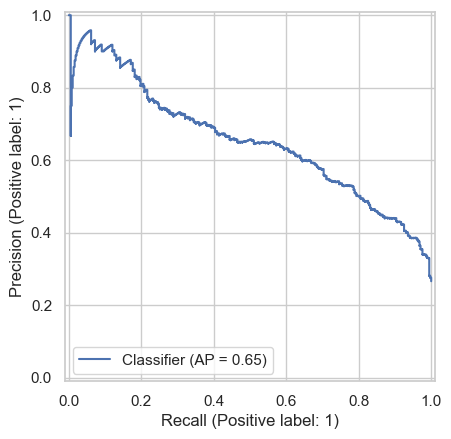

In [39]:
PrecisionRecallDisplay.from_predictions(y_test, prob)

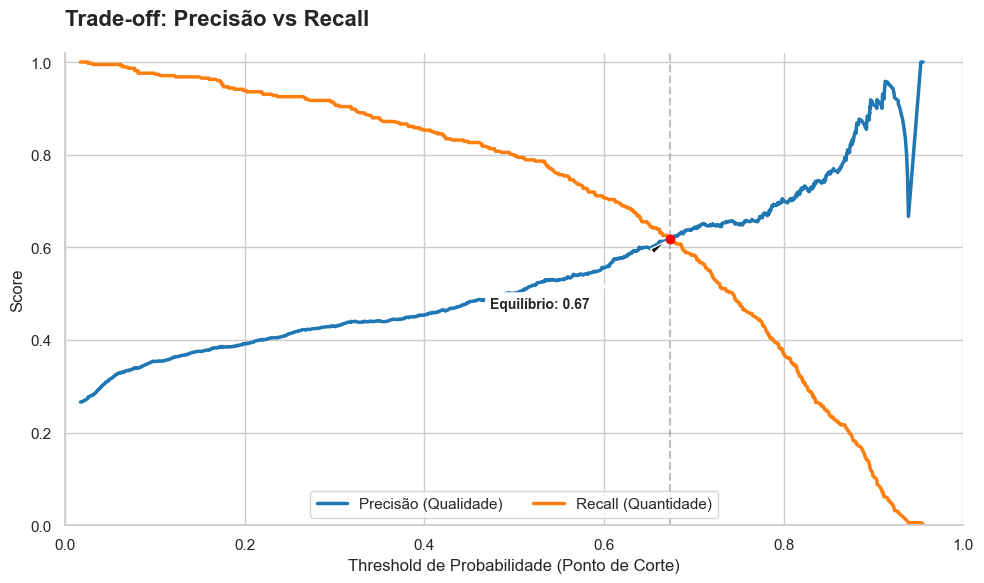

In [40]:
precision, recall, thresholds = precision_recall_curve(y_test, prob)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

plt.plot(thresholds, precision[:-1], label="Precisão (Qualidade)", color='#1f77b4', lw=2.5)
plt.plot(thresholds, recall[:-1], label="Recall (Quantidade)", color='#ff7f0e', lw=2.5)

#Encontrando o ponto de equilíbrio (Intersection)
idx = np.argwhere(np.diff(np.sign(precision - recall))).flatten()
if len(idx) > 0:
    plt.axvline(thresholds[idx[0]], color='gray', linestyle='--', alpha=0.5)
    plt.scatter(thresholds[idx[0]], precision[idx[0]], color='red', zorder=5)
    plt.annotate(f'Equilíbrio: {thresholds[idx[0]]:.2f}', 
                 xy=(thresholds[idx[0]], precision[idx[0]]), 
                 xytext=(thresholds[idx[0]]-0.2, precision[idx[0]]-0.15),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=4),
                 fontsize=10, fontweight='bold', bbox=dict(boxstyle="round", fc="w"))

plt.title("Trade-off: Precisão vs Recall", fontsize=16, pad=20, fontweight='bold', loc='left')
plt.xlabel("Threshold de Probabilidade (Ponto de Corte)", fontsize=12)
plt.ylabel("Score", fontsize=12)

plt.xlim(0, 1)
plt.ylim(0, 1.02)
sns.despine()
plt.legend(frameon=True, facecolor='white', loc='lower center', ncol=2)

plt.tight_layout()
plt.show()

In [ ]:
df_full = df.copy()
df_full = df_full.drop(["target"], axis=1)
df_full["prob_churn"] = best_model.predict_proba(df_full)[:,1]

TAXA_SUCESSO = 0.30
CUSTO_POR_CLIENTE = 50.0
HORIZONTE_MESES = 6  # 3, 6, 12...

clientes_risco_df = df_full[df_full["prob_churn"] >= 0.46]
clientes_em_risco = len(clientes_risco_df)

receita_em_risco_mensal = clientes_risco_df["monthlycharges"].sum()
receita_salva = receita_em_risco_mensal * HORIZONTE_MESES * TAXA_SUCESSO

custo_total = clientes_em_risco * CUSTO_POR_CLIENTE
roi = (receita_salva - custo_total) / custo_total

print(f"Clientes em risco: {clientes_em_risco}")

print(f"Receita em risco: R$ {receita_em_risco_mensal:,.2f}")

print(f"Receita salva estimada: R$ {receita_salva:,.2f}")

print(f"Custo total da campanha: R$ {custo_total:,.2f}")

print(f"Retorno percentual: {roi*100:.1f}%")
print(f"ROI ({HORIZONTE_MESES} meses): {roi:.2f}x")


Clientes em risco: 3034
Receita em risco: R$ 225,554.20
Receita salva estimada: R$ 405,997.56
Custo total da campanha: R$ 151,700.00
Retorno percentual: 167.6%
ROI (6 meses): 1.68x


: 

# 📉 Precision-Recall Curve — Eficiência na Identificação de Churn

Como churn é um problema desbalanceado, a Precision-Recall Curve é especialmente relevante.

O modelo apresentou:

**Average Precision (AP) = 0.65**

Isso indica que o modelo mantém boa precisão mesmo com alto recall, sendo eficiente na priorização de clientes de risco.

Os primeiros segmentos apresentam precisão superior a 80%, demonstrando excelente capacidade de ranking.

---

# 📊 Análise Integrada das Métricas

Resumo dos principais resultados:

| Métrica | Resultado |
|--------|-----------|
| AUC | 0.84 |
| KS | 0.53 |
| Lift | 2.77 |
| Average Precision | 0.65 |
| Recall | 0.93 |

Esses resultados indicam:

- Forte capacidade de separação
- Alta eficiência operacional
- Excelente potencial de aplicação prática

---

# 🧠 Interpretação de Negócio

Na prática, isso significa que:

- O modelo consegue identificar a maioria dos clientes em risco
- Permite priorizar campanhas de retenção com maior eficiência
- Maximiza o retorno sobre ações de retenção

---